In [38]:
import numpy as np
import pandas as pd

# Food delivery dataset
orders = pd.DataFrame({
    "order_id": ["O1", "O2", "O3", "O4", "O5", "O6"],
    "delivery_time": [20, 25, 35, 40, 55, 60],
    "distance": [3, 5, 8, 10, 14, 16]
})

# Extract features
X = orders[["delivery_time", "distance"]].values

# Calculate Euclidean distance matrix
distance_matrix = np.zeros((len(X), len(X)))

for i in range(len(X)):
    for j in range(len(X)):
        distance_matrix[i, j] = np.sqrt(
            (X[j, 0] - X[i, 0])**2 +
            (X[j, 1] - X[i, 1])**2
        )

distance_df = pd.DataFrame(
    distance_matrix,
    index=orders["order_id"],
    columns=orders["order_id"]
)

print(distance_df.round(3))

order_id      O1      O2      O3      O4      O5      O6
order_id                                                
O1         0.000   5.385  15.811  21.190  36.688  42.059
O2         5.385   0.000  10.440  15.811  31.321  36.688
O3        15.811  10.440   0.000   5.385  20.881  26.249
O4        21.190  15.811   5.385   0.000  15.524  20.881
O5        36.688  31.321  20.881  15.524   0.000   5.385
O6        42.059  36.688  26.249  20.881   5.385   0.000


Cluster assignments:
     song  tempo  energy  cluster
0  Song A     90    0.30        2
1  Song B     95    0.35        2
2  Song C    120    0.50        3
3  Song D    125    0.55        3
4  Song E    140    0.70        1
5  Song F    145    0.75        1
6  Song G    170    0.90        0
7  Song H    175    0.85        0


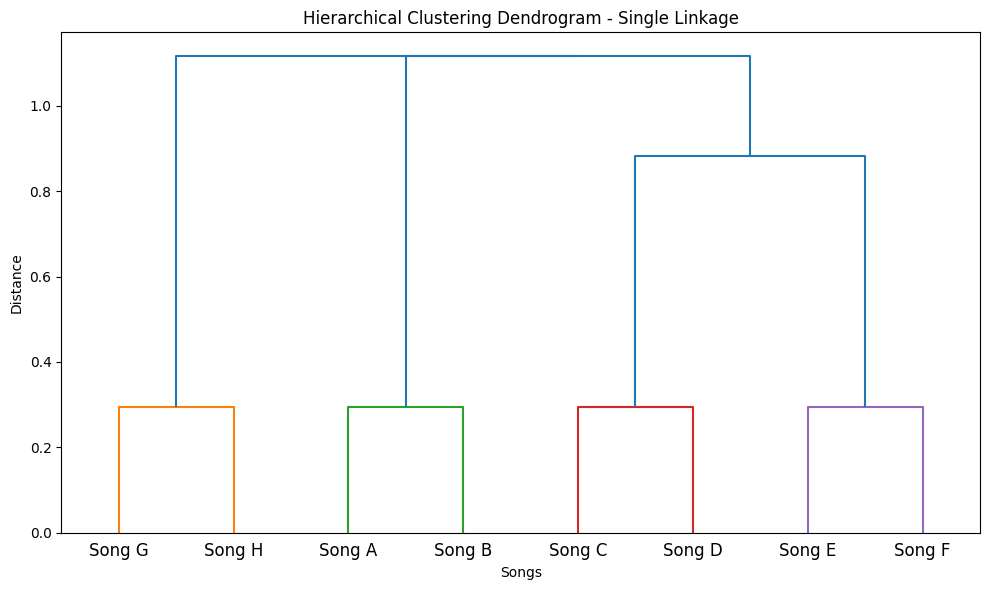

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Create song dataset
songs = pd.DataFrame({
    "song": [
        "Song A", "Song B", "Song C", "Song D",
        "Song E", "Song F", "Song G", "Song H"
    ],
    "tempo": [90, 95, 120, 125, 140, 145, 170, 175],
    "energy": [0.30, 0.35, 0.50, 0.55, 0.70, 0.75, 0.90, 0.85]
})

# Features
X = songs[["tempo", "energy"]]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------
# Agglomerative Clustering using sklearn
# ------------------------------------------------

model = AgglomerativeClustering(
    n_clusters=4,
    linkage="single"
)

labels = model.fit_predict(X_scaled)

songs["cluster"] = labels

print("Cluster assignments:")
print(songs)

# ------------------------------------------------
# Create dendrogram using SciPy
# ------------------------------------------------

Z = linkage(X_scaled, method="single")

plt.figure(figsize=(10, 6))

dendrogram(
    Z,
    labels=songs["song"].values,
    leaf_rotation=0
)

plt.title("Hierarchical Clustering Dendrogram - Single Linkage")
plt.xlabel("Songs")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()


SINGLE LINKAGE
[2 2 3 3 1 1 0 0]


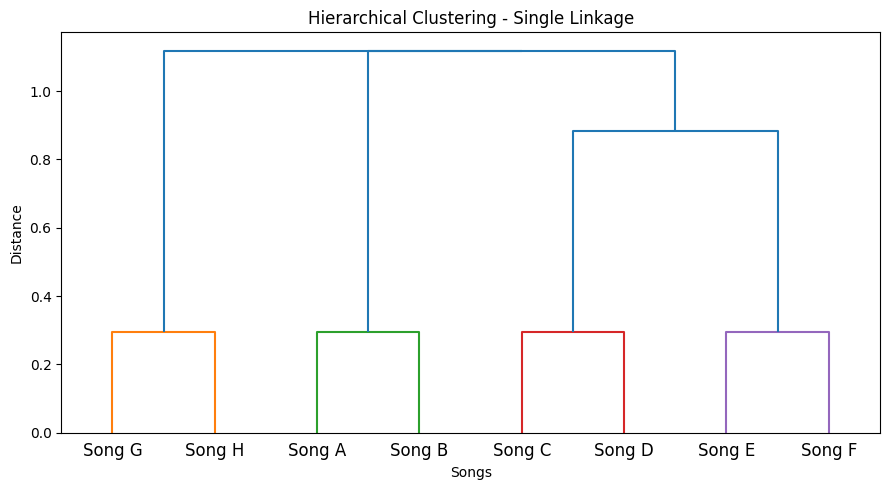


COMPLETE LINKAGE
[2 2 3 3 1 1 0 0]


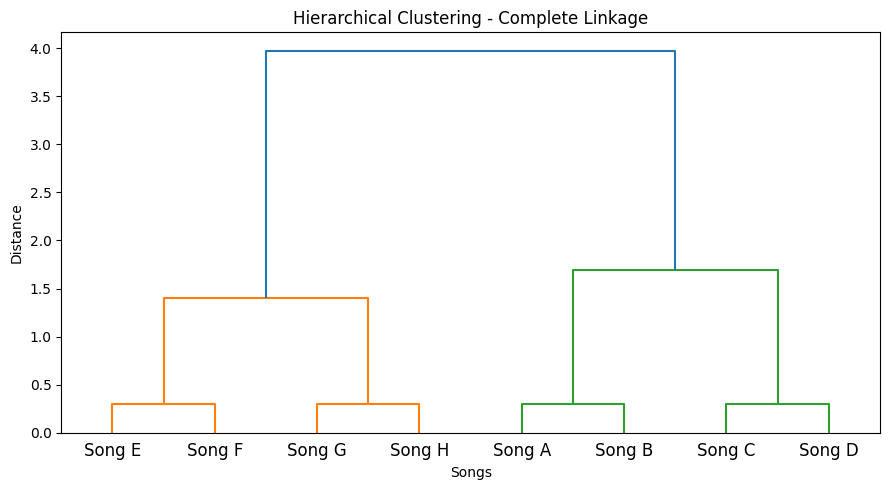


AVERAGE LINKAGE
[3 3 1 1 2 2 0 0]


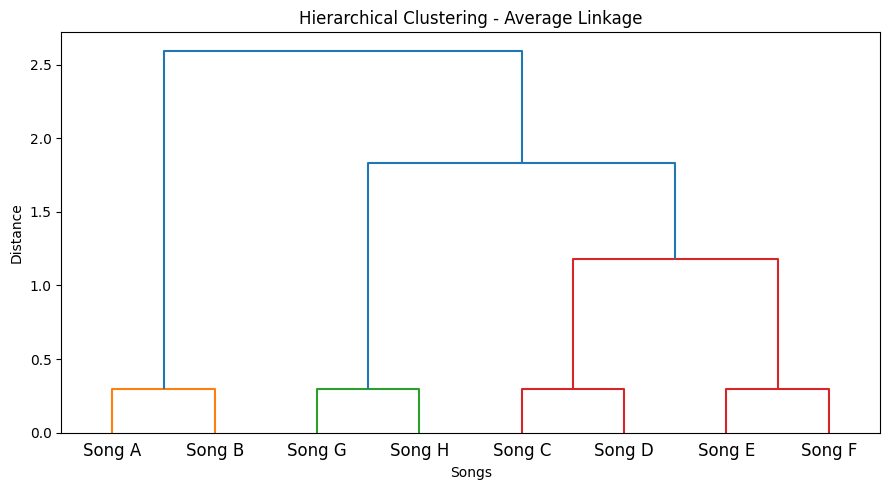

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Dataset
songs = pd.DataFrame({
    "song": [
        "Song A", "Song B", "Song C", "Song D",
        "Song E", "Song F", "Song G", "Song H"
    ],
    "tempo": [90, 95, 120, 125, 140, 145, 170, 175],
    "energy": [0.30, 0.35, 0.50, 0.55, 0.70, 0.75, 0.90, 0.85]
})

# Select features
X = songs[["tempo", "energy"]]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Linkage methods
methods = ["single", "complete", "average"]

# Create three dendrograms
for method in methods:

    # sklearn clustering
    model = AgglomerativeClustering(
        n_clusters=4,
        linkage=method
    )

    labels = model.fit_predict(X_scaled)

    print(f"\n{method.upper()} LINKAGE")
    print(labels)

    # SciPy linkage for dendrogram
    Z = linkage(X_scaled, method=method)

    plt.figure(figsize=(9, 5))

    dendrogram(
        Z,
        labels=songs["song"].values,
        leaf_rotation=0
    )

    plt.title(f"Hierarchical Clustering - {method.capitalize()} Linkage")
    plt.xlabel("Songs")
    plt.ylabel("Distance")

    plt.tight_layout()
    plt.show()

In [43]:
import math

def calculate_distances(point1, point2):
    x1, y1 = point1
    x2, y2 = point2

    euclidean = math.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )

    manhattan = (
        abs(x2 - x1) +
        abs(y2 - y1)
    )

    return euclidean, manhattan

pairs = [
    ((20, 3), (25, 5)),
    ((35, 8), (40, 10)),
    ((55, 14), (60, 16))
]

for point1, point2 in pairs:

    euclidean, manhattan = calculate_distances(
        point1,
        point2
    )

    print(f"Points: {point1} and {point2}")
    print(f"Euclidean Distance: {euclidean:.3f}")
    print(f"Manhattan Distance: {manhattan}")
    print("-" * 40)


Points: (20, 3) and (25, 5)
Euclidean Distance: 5.385
Manhattan Distance: 7
----------------------------------------
Points: (35, 8) and (40, 10)
Euclidean Distance: 5.385
Manhattan Distance: 7
----------------------------------------
Points: (55, 14) and (60, 16)
Euclidean Distance: 5.385
Manhattan Distance: 7
----------------------------------------
